# Swtep 1 - Load the Parquet file

In [ ]:
from google.colab import drive
from pathlib import Path
import pandas as pd

drive.mount('/content/drive')

DRIVE = Path('/content/drive/MyDrive/m5_project')

# Test block = last 28 days (d_1914–d_1941). It is used ONCE, for the final score.
# We drop it here so nothing we see in EDA can influence features or model choices -- Avoiding "Data leakage"
# (looking at it would leak future information into our decisions).
TEST_START = 1914

df = pd.read_parquet(DRIVE / 'processed' / 'ca12_long.parquet')
print("full parquet: ", df.shape)     # (6096944, 17) — matches the table

df = df[df.d < TEST_START].copy()   # keep only d_847–d_1913
print("EDA Data      :", df.shape)       # ~170K fewer rows = 6,098 series x 28 days
print("Dropped rows  :", 6096944 - len(df))
print("Date Range    :", df.date.min().date(), "->",  df.date.max().date())   # ends 2016-04-24

df['sales'] = df.sales.astype('int32')

Mounted at /content/drive
full parquet:  (6096944, 17)
EDA Data      : (5926200, 17)
Dropped rows  : 170744
Date Range    : 2013-05-24 -> 2016-04-24


- everything before d_1914 is for exploring and training; d_1914–d_1941 is sealed until final evaluation.

In [ ]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Business Questions to Answer before training

### **A. How big is demand, and where is it?**

1.	Is total daily demand growing, flat, or declining over three years?
2.	Which departments and categories drive the most volume?
3.	Do CA_1 and CA_2 behave alike over time?
4.	Do a few products carry most of the sales?

### **B. When do customers buy?**

5.	Which days of the week are busiest?
6.	Which months are strongest?
7.	Does demand shift within the month?
8. How do holidays and events change sales?
9.	Are food sales higher on SNAP days?

### **C. How do products behave?**

10.	How many products sell only occasionally?
11. How many products are new, with little sales history?

### **D. How does price relate to demand?**

12.	Do cheaper products sell more units?
13.	Does a product sell more when its own price drops?

### **E. Can the past predict the future?**

14.	Which past days best predict today's sales?

### **F. The H-Pro questions**

14.	Are aggregated series easier to forecast than item-level ones?
15.	How different are consecutive 28-day windows from each other?

# Step 2 - EDA

In [ ]:
# Function to explore the dataset

def explore_data(df):
    print(f"-"*15, "INFO","-"*15)
    (df.info())

    print(f"-"*15, "DESCRIBE","-"*15)
    print(df[['sales', 'sell_price']].describe(percentiles=[.25, .5, .75, .9, .99]))

    print(f"-"*15, "CHECK NULLS","-"*15)
    print(df.isnull().sum())

    print(f"-"*15, "CHECK DUPLICATES","-"*15)
    print(df.duplicated(['id', 'd']).sum())

    print(f"-"*15, "SHAPE OF DATA","-"*15)
    print(df.shape)

explore_data(df)

--------------- INFO ---------------
<class 'pandas.core.frame.DataFrame'>
Index: 5926200 entries, 0 to 6096915
Data columns (total 17 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            category      
 1   item_id       category      
 2   dept_id       category      
 3   cat_id        category      
 4   store_id      category      
 5   state_id      category      
 6   d             int16         
 7   sales         int32         
 8   date          datetime64[ns]
 9   wm_yr_wk      int16         
 10  wday          int8          
 11  month         int8          
 12  year          int16         
 13  event_name_1  category      
 14  event_type_1  category      
 15  snap_CA       int8          
 16  sell_price    float32       
dtypes: category(8), datetime64[ns](1), float32(1), int16(3), int32(1), int8(3)
memory usage: 243.3 MB
--------------- DESCRIBE ---------------
              sales    sell_price
count  5.926200e+06  5.926200e+

In [ ]:
df.head(10)

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,wday,month,year,event_name_1,event_type_1,snap_CA,sell_price
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,847,0,2013-05-24,11317,7,5,2013,NaN,NaN,0,2.24
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,848,1,2013-05-25,11318,1,5,2013,NaN,NaN,0,2.24
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,849,0,2013-05-26,11318,2,5,2013,NaN,NaN,0,2.24
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,850,0,2013-05-27,11318,3,5,2013,MemorialDay,National,0,2.24
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,851,2,2013-05-28,11318,4,5,2013,NaN,NaN,0,2.24
5,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,852,2,2013-05-29,11318,5,5,2013,NaN,NaN,0,2.24
6,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,853,0,2013-05-30,11318,6,5,2013,NaN,NaN,0,2.24
7,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,854,1,2013-05-31,11318,7,5,2013,NaN,NaN,0,2.24
8,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,855,0,2013-06-01,11319,1,6,2013,NaN,NaN,1,2.24
9,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,856,0,2013-06-02,11319,2,6,2013,NaN,NaN,1,2.24


### **A. How big is demand, and where is it?**

Text(0, 0.5, '% of total units')

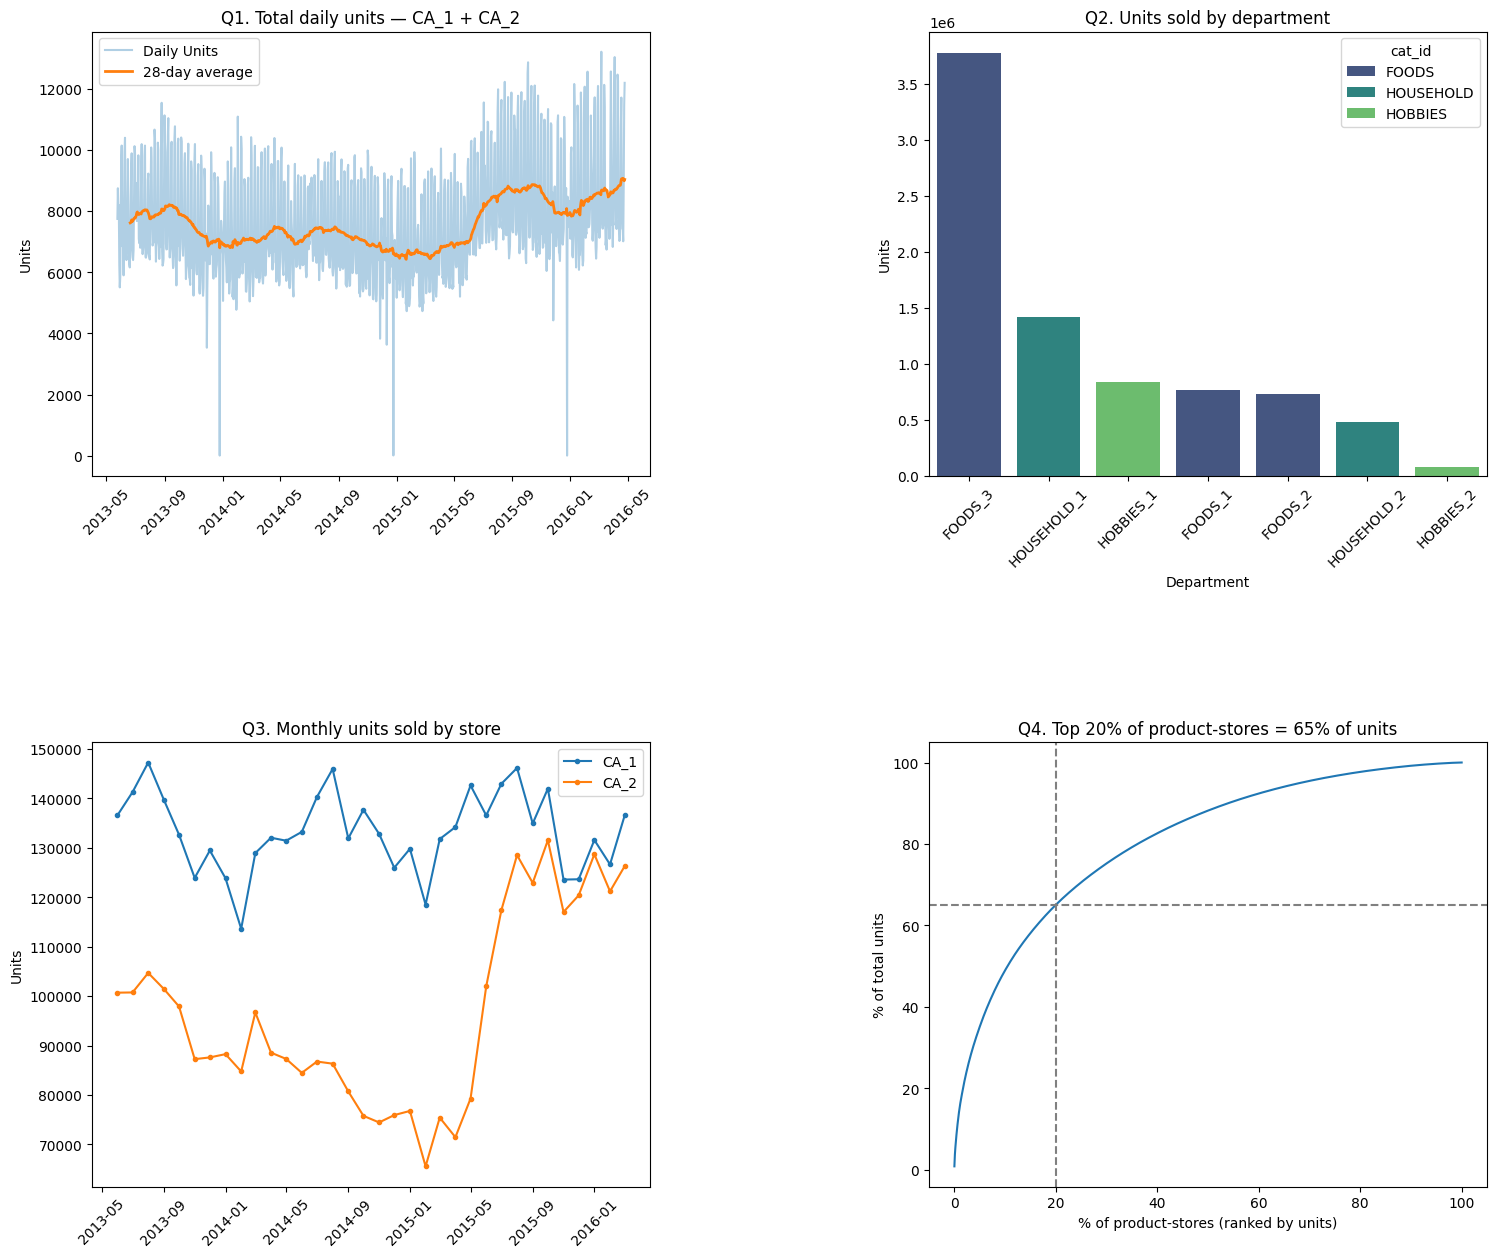

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(18,15))
fig.subplots_adjust(hspace=0.6, wspace=0.5)

# Q1 Is total daily demand trend? -- Line chart
total = df.groupby('date')['sales'].sum()

ax = axes[0,0]
ax.plot(total.index, total.values, alpha=0.35, label='Daily Units')
ax.plot(total.index, total.rolling(28).mean(), lw=2, label='28-day average')
ax.set_title('Q1. Total daily units — CA_1 + CA_2')
ax.set_ylabel('Units')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# Q2 Departments and categories drive the most volume?
dept = df.groupby(['dept_id', 'cat_id'], observed=True)['sales'].sum().reset_index().sort_values('sales', ascending=False)
dept[['dept_id', 'cat_id']] = dept[['dept_id', 'cat_id']].astype(str)

ax = axes[0, 1]
sns.barplot(data=dept, x='dept_id', y='sales', hue='cat_id', dodge=False, palette='viridis', ax=ax)
ax.set_title('Q2. Units sold by department')
ax.set_xlabel('Department')
ax.set_ylabel('Units')
ax.tick_params(axis='x', rotation=45)

# Q3 Do CA_1 & CA_2 behave alike?
monthly         = df.groupby([df.date.dt.to_period('M'), 'store_id'], observed=True)['sales'].sum().unstack()
monthly.index   = monthly.index.to_timestamp()
monthly.columns = monthly.columns.astype(str)
monthly         = monthly.iloc[1:-1]  # drop partial first & last month(May & April)

ax = axes[1,0]
for store in monthly.columns:
    ax.plot(monthly.index, monthly[store], marker='o', ms=3, label=store)
ax.set_title('Q3. Monthly units sold by store')
ax.set_ylabel('Units')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# Q4 Do a few products carry most of the sales?
units      = df.groupby('id',observed=True)['sales'].sum().sort_values(ascending=False)
cum_share  = units.cumsum() / units.sum() * 100
pct_series = np.arange(1, len(units) + 1) / len(units) * 100
top20      = cum_share.iloc[int(0.2 * len(units)) - 1]

ax = axes[1, 1]
ax.plot(pct_series, cum_share.values)
ax.axvline(20, ls='--', c='grey')
ax.axhline(top20, ls='--', c='grey')
ax.set_title(f'Q4. Top 20% of product-stores = {top20:.0f}% of units')
ax.set_xlabel('% of product-stores (ranked by units)')
ax.set_ylabel('% of total units')


### **B. When do customers buy?**

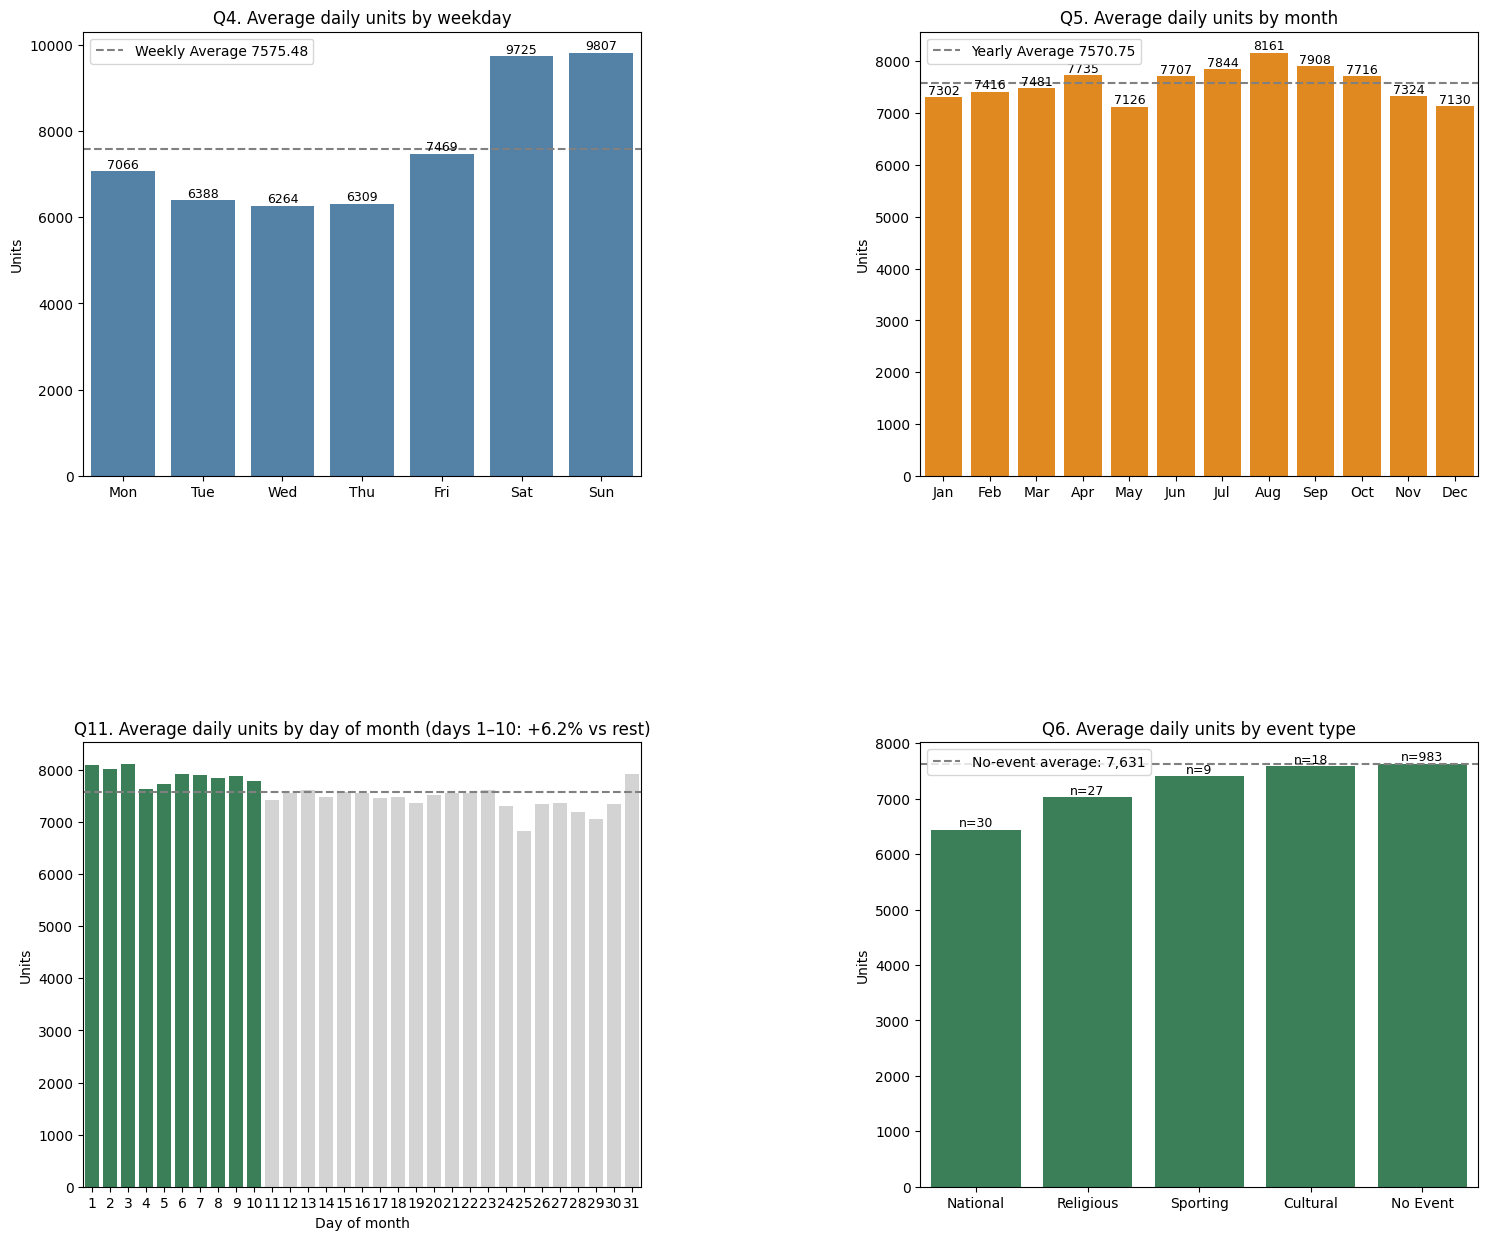

In [28]:
from os import eventfd
fig, axes = plt.subplots(2,2, figsize=(18,15))
fig.subplots_adjust(hspace=0.6, wspace=0.5)

# Q5. Which days of the week are busiest?
weekday_names = total.index.day_name()
busiest_days  = total.groupby(weekday_names).mean()
order         = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
busiest_days  = busiest_days.reindex(order)

ax = axes[0, 0]
sns.barplot(x=busiest_days.index.str[:3], y=busiest_days.values, color='steelblue', ax=ax)
ax.axhline(busiest_days.mean(), ls='--', c='grey', label=f'Weekly Average {busiest_days.mean():.2f}')
ax.bar_label(ax.containers[0], fmt='%.0f', fontsize=9)
ax.set_title('Q4. Average daily units by weekday')
ax.set_xlabel('')
ax.set_ylabel('Units')
ax.legend()

# 06. Which months are strongest
month_names     = total.index.month_name()
busiest_months  = total.groupby(month_names).mean()
order_months    = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
busiest_months  = busiest_months.reindex(order_months)

ax = axes[0,1]
sns.barplot(x=busiest_months.index.str[:3], y=busiest_months.values, color='darkorange', ax=ax)
ax.axhline(busiest_months.mean(), ls='--', c='grey', label=f'Yearly Average {busiest_months.mean():.2f}')
ax.bar_label(ax.containers[0], fmt='%.0f', fontsize=9)
ax.set_title('Q5. Average daily units by month')
ax.set_xlabel('')
ax.set_ylabel('Units')
ax.legend()

# 07. Does the demand shift within month?
by_dom = total.groupby(total.index.day).mean()
colors = ['seagreen' if d <= 10 else 'lightgrey' for d in by_dom.index]
early  = by_dom.loc[1:10].mean() / by_dom.loc[11:].mean() - 1

ax = axes[1, 0]
sns.barplot(x=by_dom.index, y=by_dom.values, hue=by_dom.index, palette=colors, legend=False, ax=ax)
ax.axhline(by_dom.mean(), ls='--', c='grey')
ax.set_title(f'Q11. Average daily units by day of month (days 1–10: {early:+.1%} vs rest)')
ax.set_xlabel('Day of month')
ax.set_ylabel('Units')

# Q8. How do Holidays and events change?
cal                   = df.drop_duplicates('date').set_index('date')[['event_name_1', 'event_type_1']]
event                 = total.to_frame('units').join(cal)
event['event_type_1'] = event['event_type_1'].astype(object).fillna('No Event')
by_event              = event.groupby('event_type_1')['units'].agg(['mean', 'count']).sort_values('mean')

ax = axes[1,1]
sns.barplot(x=by_event.index, y=by_event['mean'], color='seagreen', ax=ax)
ax.axhline(by_event.loc['No Event', 'mean'], ls='--', c='grey', label=f'No-event average: {by_event.loc['No Event', 'mean']:,.0f}')
ax.bar_label(ax.containers[0], labels=[f'n={n}' for n in by_event['count']], fontsize=9)
ax.set_title('Q6. Average daily units by event type')
ax.set_xlabel('')
ax.set_ylabel('Units')
ax.legend()

In [24]:
cal = df.drop_duplicates('date').set_index('date')[['event_name_1', 'event_type_1']]
cal

,event_name_1,event_type_1
date,,
2013-05-24,NaN,NaN
2013-05-25,NaN,NaN
2013-05-26,NaN,NaN
2013-05-27,MemorialDay,National
2013-05-28,NaN,NaN
...,...,...
2016-04-20,NaN,NaN
2016-04-21,NaN,NaN
2016-04-22,NaN,NaN


In [ ]:
# test push